In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils.common import extract_latents_with_names, combine_audio_and_lyrics
from run_models import run_VAE, run_KMeans, run_Agglomerative, run_DBSCAN

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np
from pathlib import Path

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

In [6]:
conv_vae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="conv", root=root, plot_dir_name="medium_2_conv_vae_audio_lyrics")

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-10 08:48:02,072] A new study created in memory with name: Convolutional VAE Tuning
  0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 241.3208     | 218.9965    
Recon        | 235.8834     | 216.8667    
KL Div       | 27.1867      | 10.6488     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 196.2306     | 194.1232    
Recon        | 189.9901     | 188.6624    
KL Div       | 31.2026      | 27.3044     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 174.1977     | 176.0182    
Recon        | 168.3263     | 170.2615    
KL Div       | 29.3574      | 28.7833     
--------------------------------------

  0%|          | 0/5 [00:04<?, ?it/s]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 143.1161     | 144.6650    
Recon        | 137.5340     | 139.0483    
KL Div       | 27.9106      | 28.0836     
--------------------------------------------------

[I 2026-04-10 08:48:06,935] Trial 0 finished with value: 94.66242982844716 and parameters: {'CHANNEL_1': 4, 'CHANNEL_2_MULTIPLIER': 8, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 16, 'LR': 0.0001519934830130982, 'BATCH_SIZE': 64, 'BETA': 3.0}. Best is trial 0 with value: 94.66242982844716.


Best trial: 0. Best value: 94.6624:  20%|██        | 1/5 [00:05<00:20,  5.04s/it]

...

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 177.2173     | 110.6685    
Recon        | 168.1143     | 102.8588    
KL Div       | 45.5149      | 39.0486     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 91.6412      | 75.7324     
Recon        | 83.9221      | 67.8745     
KL Div       | 38.5952      | 39.2896     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 71.9020      | 67.2408     
Recon        | 64.1783      | 59.6105     
KL Div       | 38.6181      | 38.1517     
--------------------------------------

Best trial: 1. Best value: 55.2354:  80%|████████  | 4/5 [00:40<00:07,  7.89s/it]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 61.4379      | 57.5021     
Recon        | 53.5882      | 49.8592     
KL Div       | 39.2485      | 38.2143     
--------------------------------------------------

[I 2026-04-10 08:48:42,155] Trial 4 finished with value: 45.20123649675821 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 2, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 32, 'LR': 0.0002572663133249957, 'BATCH_SIZE': 16, 'BETA': 3.0}. Best is trial 4 with value: 45.20123649675821.


Best trial: 4. Best value: 45.2012: 100%|██████████| 5/5 [00:40<00:00,  8.05s/it]


..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\optimization_history.html
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\param_importances.html
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\parallel_coordinate.html
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\edf.html
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\timeline.html
Saved: ..\..\results\trials\medium_2_conv_vae_audio_lyrics\plots\contour.html
Best trial for `conv`:
Score: 45.2012
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      2
    CHANNEL_3_MULTIPLIER      4
    LATENT_DIM                32
    LR                        0.0002572663133249957
    BATCH_SIZE                16
    BETA                      3.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Batc

In [7]:
train_latents, _, train_audio_names = extract_latents_with_names(model=conv_vae, loader=train_loader, device=device)
test_latents, _, test_audio_names  = extract_latents_with_names(model=conv_vae, loader=test_loader,  device=device)

In [8]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_audio_names = np.concatenate([train_audio_names, test_audio_names], axis=0)

In [9]:
vae_latents.shape

(2424, 32)

In [10]:
latent_vecs_hybrid = combine_audio_and_lyrics(latent_vecs=vae_latents, audio_names=vae_audio_names, root=root)

In [11]:
latent_vecs_hybrid.shape

(2424, 800)




Optimal k        : 5
Inertia (WCSS)   : 35694.9180
Silhouette Score : 0.1889
CH Index         : 463.6496
DB Index         : 1.7011



n_clusters not provided for Agglomerative — running elbow method to determine k...



Agglomerative  n_clusters=5  linkage='ward'
Silhouette Score : 0.1500
CH Index         : 381.1234
DB Index         : 1.6454






DBSCAN  eps=2.5  min_samples=5
Clusters found   : 7
Noise points     : 1076



DB-SCAN
Silhouette Score : 0.0464
CH Index         : 133.0262
DB Index         : 1.3830





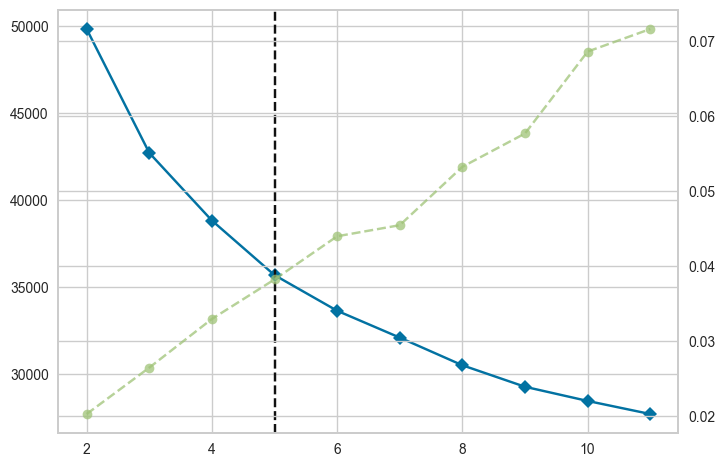

In [12]:
vae_kmeans, vae_kmeans_metrics = run_KMeans(vae_latents, model_type="medium_2_conv_vae_audio_lyrics", root=root)
vae_agglomerative, vae_agglomerative_metrics = run_Agglomerative(vae_latents, model_type="medium_2_conv_vae_audio_lyrics", root=root)
vae_dbscan, vae_dbscan_metrics = run_DBSCAN(vae_latents, model_type="medium_2_conv_vae_audio_lyrics", root=root)

In [13]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [14]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\medium_2_conv_vae_audio_lyrics


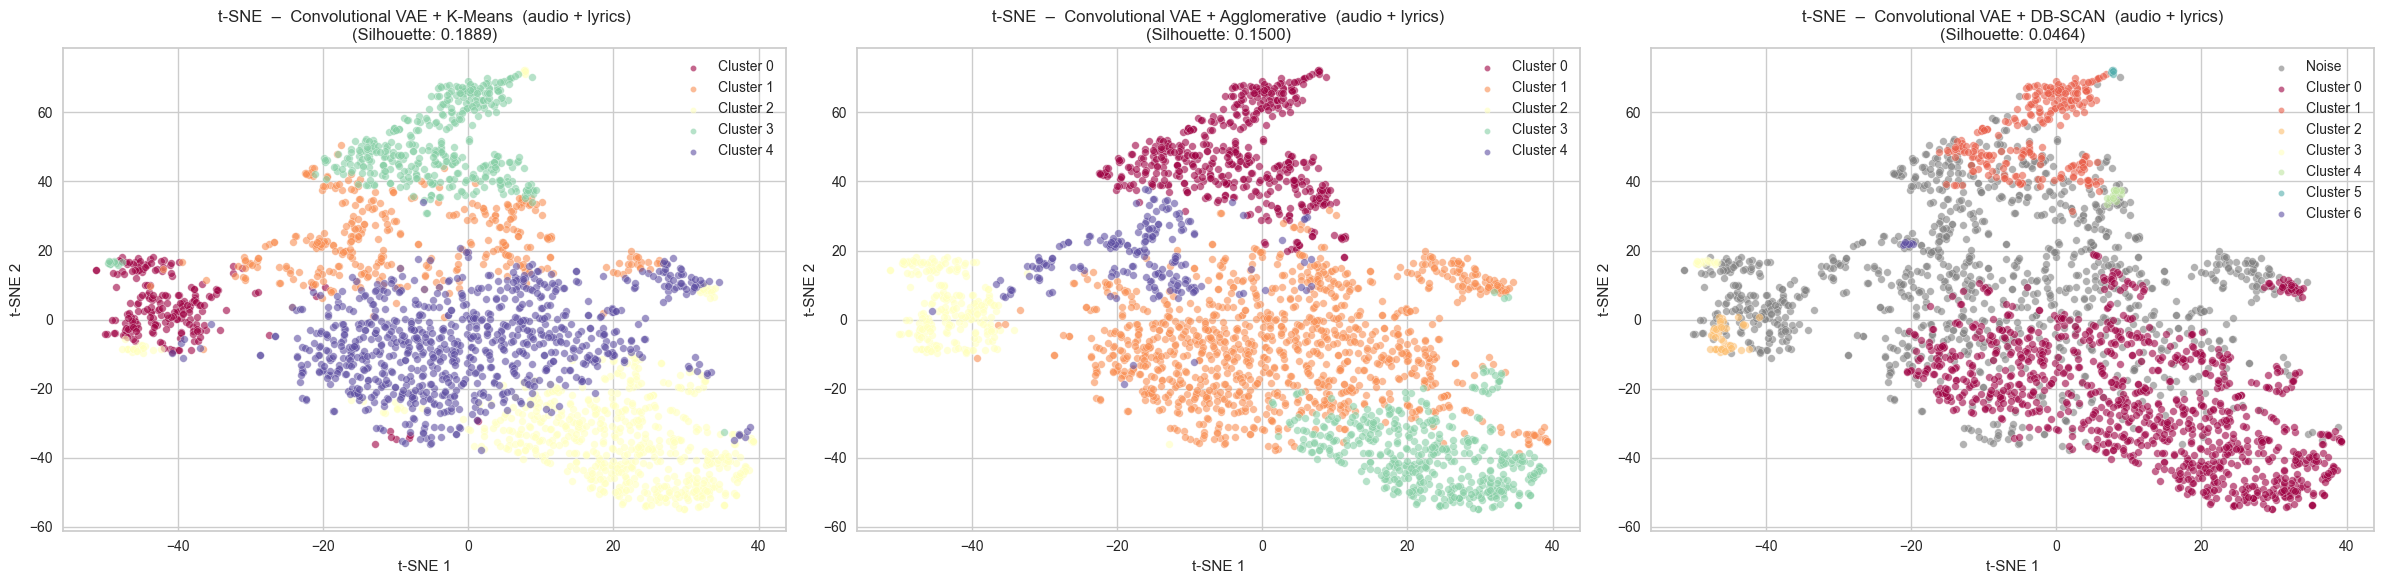

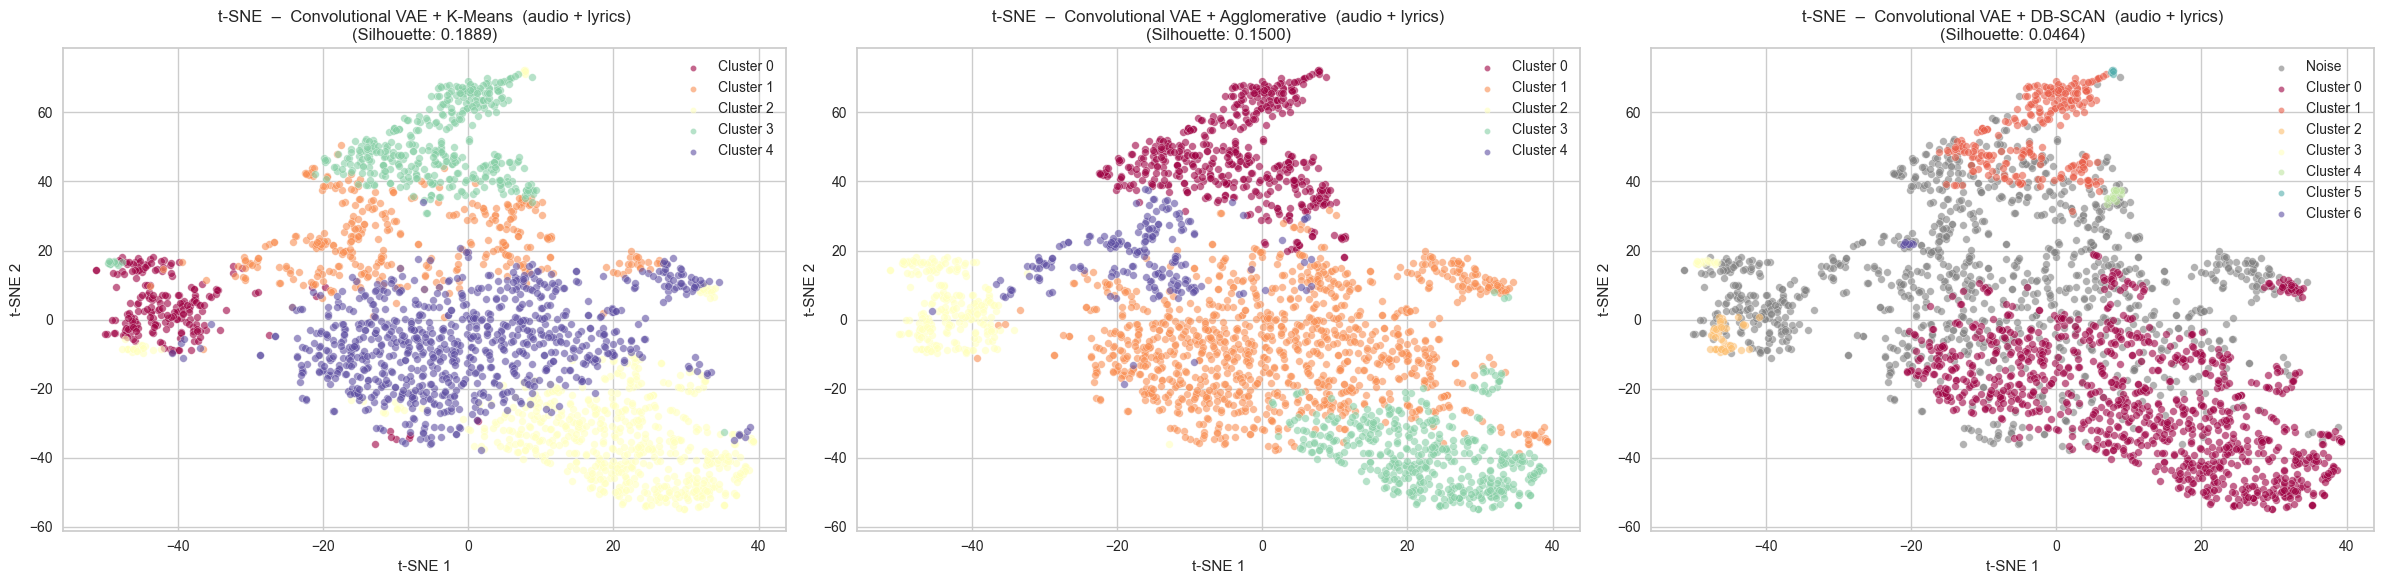

In [15]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Convolutional VAE + K-Means  (audio + lyrics)", "Convolutional VAE + Agglomerative  (audio + lyrics)", "Convolutional VAE + DB-SCAN  (audio + lyrics)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)],
    save_path=TSNE_DIR / "medium_2_conv_vae_audio_lyrics"
)